In [ ]:
import kagglehub
chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')

Data source import complete.


In [ ]:
chest_xray_pneumonia_path

'/kaggle/input/chest-xray-pneumonia'

In [ ]:
data_dir = '/kaggle/input/chest-xray-pneumonia'
TEST = 'test'
TRAIN = 'train'
VAL ='val'

In [ ]:
train_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train'
test_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test'
val_dir = '/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val'

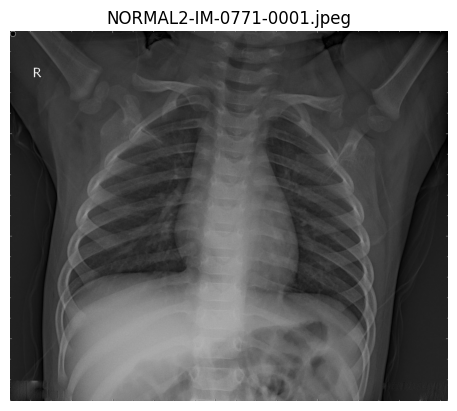

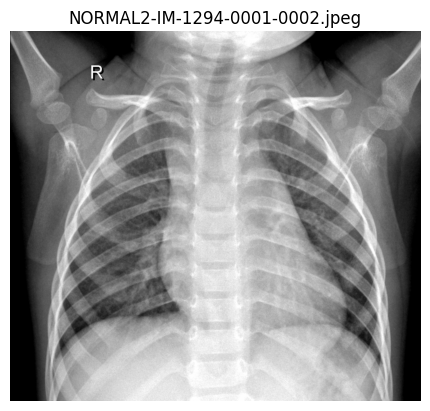

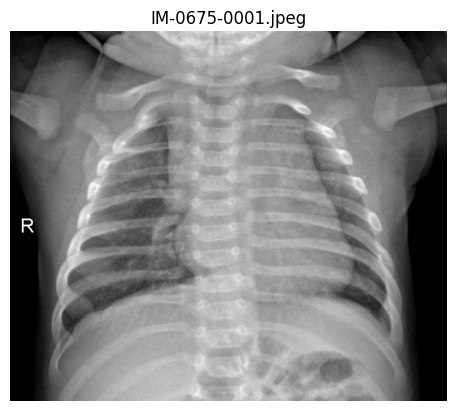

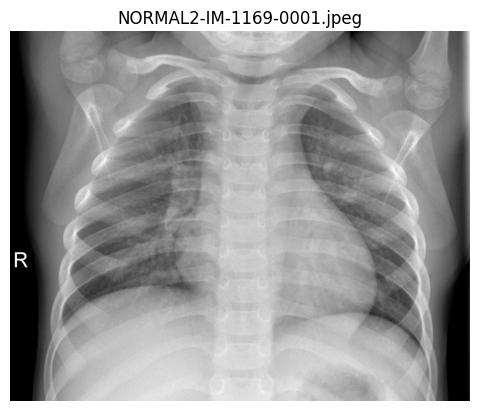

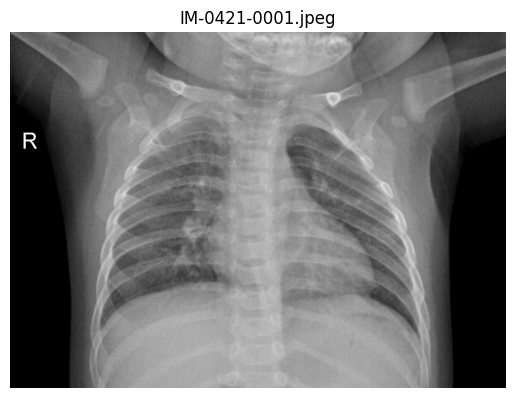

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

normal_imgs = os.listdir(os.path.join(train_dir, 'NORMAL'))[:5]

for img_name in normal_imgs:
    img_path = os.path.join(train_dir, 'NORMAL', img_name)
    img = Image.open(img_path)
    plt.imshow(img, cmap='gray')
    plt.title(img_name)
    plt.axis('off')
    plt.show()


In [ ]:
import cv2

In [ ]:
img1 = cv2.imread(os.path.join(train_dir, 'NORMAL', normal_imgs[1]))

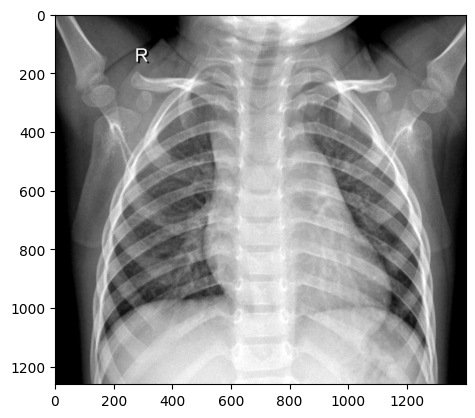

In [ ]:
plt.imshow(img1, cmap='gray')

In [ ]:
img1.shape

(1260, 1400, 3)

In [ ]:
from tensorflow.keras.utils import image_dataset_from_directory


In [ ]:
IMG_SIZE = 224  # Kích thước yêu cầu cho VGG16
BATCH_SIZE = 32
COLOR_MODE = 'rgb'  # Chuyển ảnh từ grayscale sang RGB

train_set = image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="binary",
    class_names=['NORMAL', 'PNEUMONIA'],
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation="bilinear"
)


Found 5216 files belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

# Tạo mô hình VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Đóng băng các lớp của base model
base_model.trainable = False

# Xây dựng mô hình hoàn chỉnh
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')  # 'sigmoid' vì bạn có 2 lớp (NORMAL, PNEUMONIA)
])

# Compile mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Kiểm tra cấu trúc mô hình
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Tạo val_set
val_set = image_dataset_from_directory(
    val_dir,
    labels="inferred",
    label_mode="binary",
    class_names=['NORMAL', 'PNEUMONIA'],
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation="bilinear"
)

# Tạo test_set
test_set = image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="binary",
    class_names=['NORMAL', 'PNEUMONIA'],
    color_mode=COLOR_MODE,
    batch_size=BATCH_SIZE,
    image_size=(IMG_SIZE, IMG_SIZE),
    interpolation="bilinear"
)

Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [ ]:
history = model.fit(
    train_set,
    epochs=10,  # Bạn có thể điều chỉnh số epochs tùy vào dataset
    validation_data=val_set
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 322ms/step - accuracy: 0.8065 - loss: 0.4860 - val_accuracy: 0.8750 - val_loss: 0.3217
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 50s 197ms/step - accuracy: 0.9408 - loss: 0.1618 - val_accuracy: 0.8750 - val_loss: 0.1951
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 202ms/step - accuracy: 0.9561 - loss: 0.1221 - val_accuracy: 0.8750 - val_loss: 0.1321
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 54s 284ms/step - accuracy: 0.9600 - loss: 0.1069 - val_accuracy: 0.9375 - val_loss: 0.1052
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 205ms/step - accuracy: 0.9647 - loss: 0.0916 - val_accuracy: 0.9375 - val_loss: 0.1573
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 220ms/step - accuracy: 0.9653 - loss: 0.0896 - val_accuracy: 0.9375 - val_loss: 0.0761
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 203ms/step - accuracy: 0.9678 - loss: 0.0809 - val_accuracy: 1.0000 - val_loss: 0.0402
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 206ms/step - accuracy: 0.9745 - loss: 0

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Dự đoán trên test_set
y_true = []
y_pred = []

# Lặp qua batch trong test_set
for images, labels in test_set:
    y_true.extend(labels.numpy())
    y_pred.extend(model.predict(images).flatten())

# Chuyển y_pred về 0/1 (binary classification)
y_pred = np.round(y_pred)

# Tính các độ đo
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# In kết quả
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 621ms/step
Accuracy: 0.8446
Precision: 0.8097
Recall: 0.9821
F1-Score: 0.8876


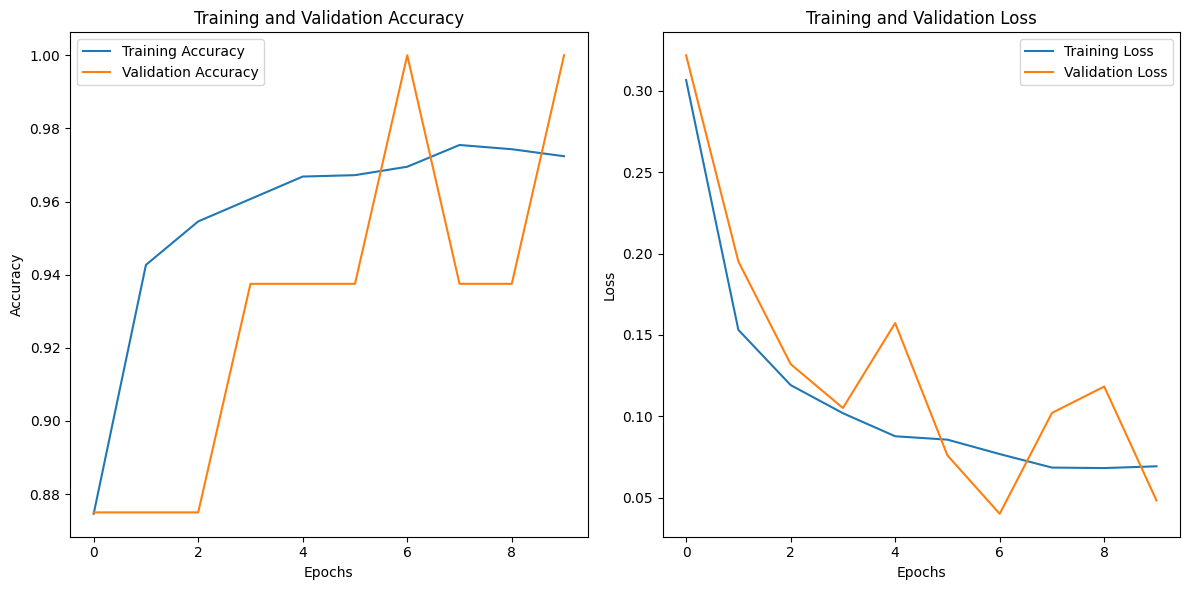

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ lịch sử huấn luyện
history_dict = history.history

# Vẽ đồ thị Accuracy
plt.figure(figsize=(12, 6))

# Accuracy (training và validation)
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


## VGG 19

In [ ]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models

# Tạo mô hình VGG19
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Đóng băng các lớp của base model
base_model.trainable = False

# Xây dựng mô hình hoàn chỉnh
model_vgg19 = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')  # 'sigmoid' vì bạn có 2 lớp (NORMAL, PNEUMONIA)
])

# Compile mô hình
model_vgg19.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Kiểm tra cấu trúc mô hình
model_vgg19.summary()


80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,897 (76.39 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
history_vgg19 = model_vgg19.fit(
    train_set,
    epochs=10,  # Điều chỉnh số epochs nếu cần
    validation_data=val_set
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 249ms/step - accuracy: 0.7629 - loss: 0.6314 - val_accuracy: 0.6250 - val_loss: 0.7566
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 219ms/step - accuracy: 0.9270 - loss: 0.1905 - val_accuracy: 0.6875 - val_loss: 0.6080
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - accuracy: 0.9464 - loss: 0.1344 - val_accuracy: 0.6875 - val_loss: 0.4778
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 211ms/step - accuracy: 0.9568 - loss: 0.1083 - val_accuracy: 0.8750 - val_loss: 0.3040
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - accuracy: 0.9620 - loss: 0.0953 - val_accuracy: 0.9375 - val_loss: 0.2638
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.9678 - loss: 0.0843 - val_accuracy: 0.9375 - val_loss: 0.2520
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 215ms/step - accuracy: 0.9704 - loss: 0.0797 - val_accuracy: 0.8750 - val_loss: 0.2657
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.9710 - loss: 0

In [ ]:
# Dự đoán trên test_set
y_true = []
y_pred = []

# Lặp qua batch trong test_set
for images, labels in test_set:
    y_true.extend(labels.numpy())
    y_pred.extend(model_vgg19.predict(images).flatten())

# Chuyển y_pred về 0/1 (binary classification)
y_pred = np.round(y_pred)

# Tính các độ đo
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# In kết quả
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
Accuracy: 0.8205
Precision: 0.7837
Recall: 0.9846
F1-Score: 0.8727


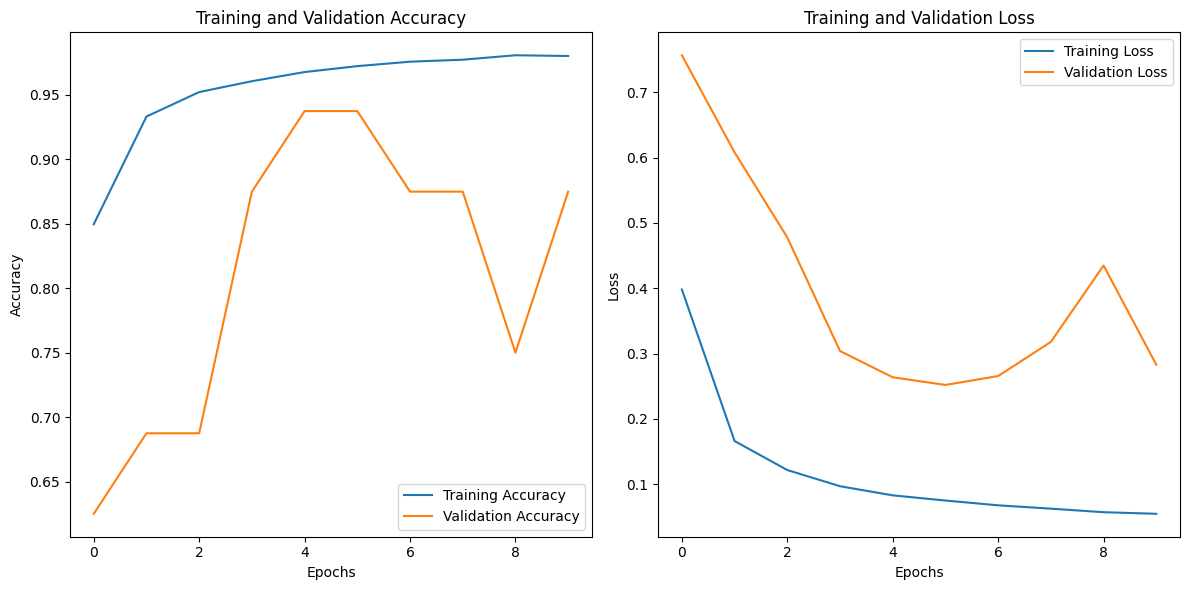

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ lịch sử huấn luyện
history_dict = history_vgg19.history

# Vẽ đồ thị Accuracy
plt.figure(figsize=(12, 6))

# Accuracy (training và validation)
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# res net50

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Tạo mô hình ResNet50
base_model_resnet50 = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Đóng băng các lớp của base model
base_model_resnet50.trainable = False

# Xây dựng mô hình hoàn chỉnh
model_resnet50 = models.Sequential([
    base_model_resnet50,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')  # 'sigmoid' vì bạn có 2 lớp (NORMAL, PNEUMONIA)
])

# Compile mô hình
model_resnet50.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Kiểm tra cấu trúc mô hình
model_resnet50.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history_resnet50 = model_resnet50.fit(
    train_set,
    epochs=10,  # Điều chỉnh số epochs nếu cần
    validation_data=val_set
)


Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 52s 237ms/step - accuracy: 0.8188 - loss: 0.4581 - val_accuracy: 0.6875 - val_loss: 0.5476
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 69s 198ms/step - accuracy: 0.9549 - loss: 0.1194 - val_accuracy: 0.8125 - val_loss: 0.4396
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 193ms/step - accuracy: 0.9656 - loss: 0.0937 - val_accuracy: 0.8750 - val_loss: 0.4113
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 188ms/step - accuracy: 0.9689 - loss: 0.0803 - val_accuracy: 0.8750 - val_loss: 0.3660
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 200ms/step - accuracy: 0.9721 - loss: 0.0714 - val_accuracy: 0.8750 - val_loss: 0.3019
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 189ms/step - accuracy: 0.9741 - loss: 0.0675 - val_accuracy: 0.7500 - val_loss: 0.4499
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 194ms/step - accuracy: 0.9776 - loss: 0.0574 - val_accuracy: 0.9375 - val_loss: 0.2042
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 195ms/step - accuracy: 0.9786 - loss: 0

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Dự đoán trên test_set
y_true = []
y_pred = []

# Lặp qua batch trong test_set
for images, labels in test_set:
    y_true.extend(labels.numpy())
    y_pred.extend(model_resnet50.predict(images).flatten())

# Chuyển y_pred về 0/1 (binary classification)
y_pred = np.round(y_pred)

# Tính các độ đo
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# In kết quả
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Accuracy: 0.7949
Precision: 0.7539
Recall: 0.9974
F1-Score: 0.8587


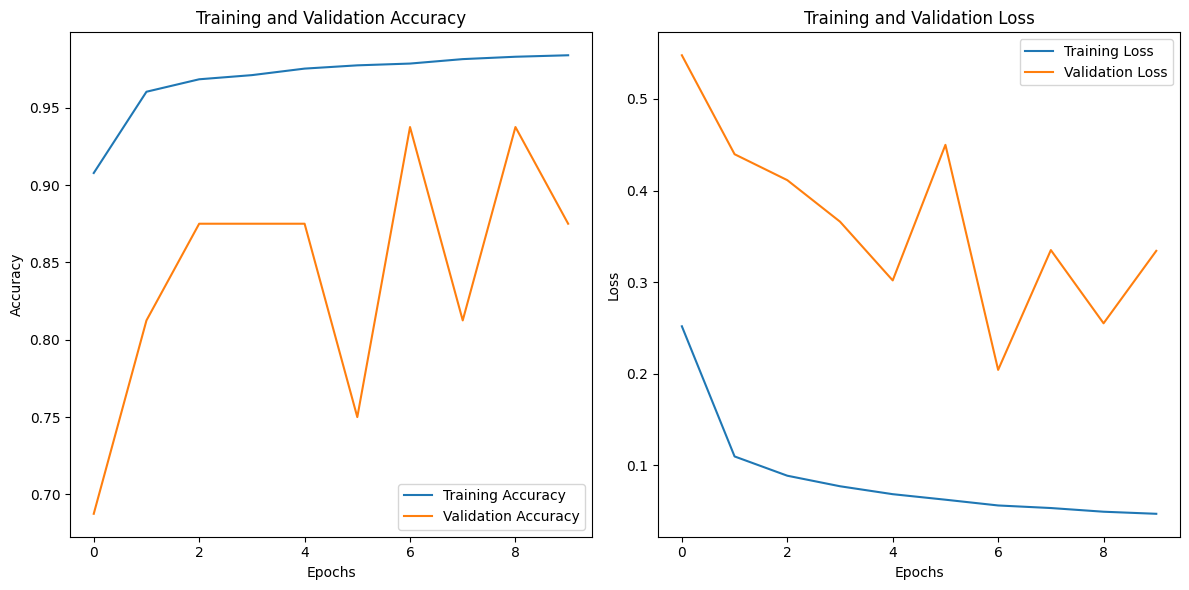

In [ ]:
import matplotlib.pyplot as plt

# Lấy dữ liệu từ lịch sử huấn luyện
history_dict = history_resnet50.history

# Vẽ đồ thị Accuracy
plt.figure(figsize=(12, 6))

# Accuracy (training và validation)
plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Vẽ đồ thị Loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


# Bai 2

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [4]:
test_path = '/content/drive/MyDrive/HocSau_BTL/dataset/test'
train_path = '/content/drive/MyDrive/HocSau_BTL/dataset/training'

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1  # 10% dành cho validation
)

# Chỉ rescale cho test
test_datagen = ImageDataGenerator(rescale=1./255)

In [9]:
IMG_SIZE = 224  # hoặc kích thước bạn dùng cho mô hình
BATCH_SIZE = 32

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',  # Dành cho tập train (90%)
    shuffle=True,
    color_mode='rgb'
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',  # Dành cho tập validation (10%)
    shuffle=True,
    color_mode='rgb'
)


Found 634 images belonging to 5 classes.
Found 69 images belonging to 5 classes.


In [10]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,  # để giữ đúng thứ tự ảnh nếu đánh giá
    color_mode='rgb'
)


Found 250 images belonging to 5 classes.


In [12]:
print("Classes:", train_generator.class_indices)
print("Số mẫu train:", train_generator.samples)
print("Số mẫu val:", validation_generator.samples)
print("Số mẫu test:", test_generator.samples)


Classes: {'BRACELET': 0, 'EARRINGS': 1, 'NECKLACE': 2, 'RINGS': 3, 'WRISTWATCH': 4}
Số mẫu train: 634
Số mẫu val: 69
Số mẫu test: 250


In [14]:
from tensorflow.keras.applications import VGG16, VGG19, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


NUM_CLASSES = 5

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)


In [15]:
def build_model(base_model):
    base_model.trainable = False  # Freeze pretrained layers

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dense(NUM_CLASSES, activation='softmax')  # Phân lớp đa lớp
    ])

    model.compile(optimizer=Adam(learning_rate=1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model


In [17]:
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg16_model = build_model(vgg16_base)

history_vgg16 = vgg16_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.1752 - loss: 1.9822

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 0.1782 - loss: 1.9734 - val_accuracy: 0.5362 - val_loss: 1.4572
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 576ms/step - accuracy: 0.4630 - loss: 1.3409 - val_accuracy: 0.5797 - val_loss: 1.0922
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 568ms/step - accuracy: 0.6373 - loss: 0.9749 - val_accuracy: 0.6232 - val_loss: 0.8816
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 567ms/step - accuracy: 0.6919 - loss: 0.7926 - val_accuracy: 0.7101 - val_loss: 0.7499
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 567ms/step - accuracy: 0.7703 - loss: 0.6791 - val_accuracy: 0.7536 - val_loss: 0.6888
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 528ms/step - accuracy: 0.8512 - loss: 0.5760 - val_accuracy: 0.7971 - val_loss: 0.6206
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 566ms/step - accuracy: 0.8637 - loss: 0.5227 - val_accuracy: 0.8261 - val_loss: 0.5801
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 635ms/step - accuracy: 0.9068 - loss: 0.4694 - val_accuracy: 0.8406 

In [19]:
import numpy as np

In [18]:
y_pred_probs = vgg16_model.predict(test_generator)


8/8 ━━━━━━━━━━━━━━━━━━━━ 55s 8s/step


NameError: name 'np' is not defined

In [20]:
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='macro'))
print("Recall:", recall_score(y_true, y_pred, average='macro'))
print("F1-score:", f1_score(y_true, y_pred, average='macro'))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=test_generator.class_indices.keys()))

Accuracy: 0.356
Precision: 0.14975225068043826
Recall: 0.356
F1-score: 0.20701694568515805

Classification Report:
               precision    recall  f1-score   support

    BRACELET       0.31      1.00      0.47        50
    EARRINGS       0.44      0.78      0.56        50
    NECKLACE       0.00      0.00      0.00        50
       RINGS       0.00      0.00      0.00        50
  WRISTWATCH       0.00      0.00      0.00        50

    accuracy                           0.36       250
   macro avg       0.15      0.36      0.21       250
weighted avg       0.15      0.36      0.21       250



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [22]:
import matplotlib.pyplot as plt

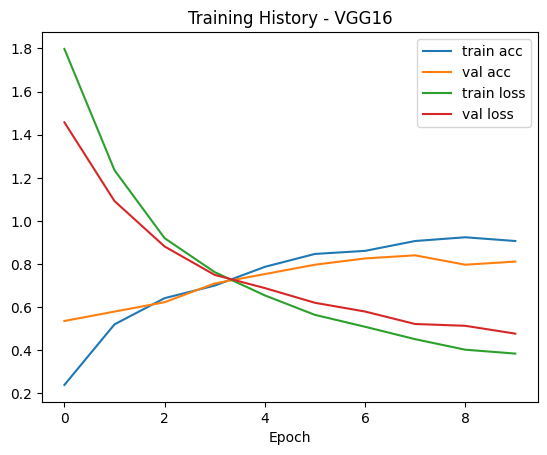

In [23]:
plt.plot(history_vgg16.history['accuracy'], label='train acc')
plt.plot(history_vgg16.history['val_accuracy'], label='val acc')
plt.plot(history_vgg16.history['loss'], label='train loss')
plt.plot(history_vgg16.history['val_loss'], label='val loss')
plt.title('Training History - VGG16')
plt.xlabel('Epoch')
plt.legend()
plt.show()


In [24]:
def evaluate_model(model, name):
    loss, acc = model.evaluate(test_generator, verbose=0)
    print(f"{name} Accuracy on test set: {acc:.4f}")


In [25]:
evaluate_model(vgg16_model, "VGG16")

VGG16 Accuracy on test set: 0.3560


# VGG19

In [27]:
vgg19_base = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
vgg19_model = build_model(vgg19_base)

history_vgg19 = vgg19_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.2349 - loss: 1.5676

/usr/local/lib/python3.11/dist-packages/PIL/Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 746ms/step - accuracy: 0.2391 - loss: 1.5620 - val_accuracy: 0.5072 - val_loss: 1.1825
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 659ms/step - accuracy: 0.5783 - loss: 1.1097 - val_accuracy: 0.6522 - val_loss: 0.9373
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 543ms/step - accuracy: 0.6414 - loss: 0.8753 - val_accuracy: 0.7101 - val_loss: 0.8028
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 577ms/step - accuracy: 0.7145 - loss: 0.7410 - val_accuracy: 0.7826 - val_loss: 0.7239
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 593ms/step - accuracy: 0.7371 - loss: 0.6623 - val_accuracy: 0.7826 - val_loss: 0.6709
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 580ms/step - accuracy: 0.7575 - loss: 0.6137 - val_accuracy: 0.7826 - val_loss: 0.6311
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 579ms/step - accuracy: 0.8015 - loss: 0.5537 - val_accuracy: 0.6957 - val_loss: 0.5945
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 574ms/step - accuracy: 0.8602 - loss: 0.4781 - val_accuracy: 0.753

In [28]:
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
resnet_model = build_model(resnet_base)

history_resnet = resnet_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stop]
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.3160 - loss: 1.7554 - val_accuracy: 0.5217 - val_loss: 0.9285
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 558ms/step - accuracy: 0.5276 - loss: 1.0687 - val_accuracy: 0.7246 - val_loss: 0.7618
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 560ms/step - accuracy: 0.5065 - loss: 0.9368 - val_accuracy: 0.6667 - val_loss: 0.7053
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 555ms/step - accuracy: 0.5504 - loss: 0.7812 - val_accuracy: 0.5797 - val_loss: 0.6890
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 497ms/step - accuracy: 0.5811 - loss: 0.7292 - val_accuracy: 0.6667 - val_loss: 0.6521
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 545ms/step - accuracy: 0.5711 - loss: 0.7200 - val_accuracy: 0.7826 - val_loss: 0.6277
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 649ms/step - accuracy: 0.6170 - loss: 0.6823 - val_accuracy: 0.7826 - val_loss: 0.6196
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 559ms/s

In [29]:
evaluate_model(vgg16_model, "VGG16")
evaluate_model(vgg19_model, "VGG19")
evaluate_model(resnet_model, "ResNet50")


VGG16 Accuracy on test set: 0.3560
VGG19 Accuracy on test set: 0.3800
ResNet50 Accuracy on test set: 0.3840


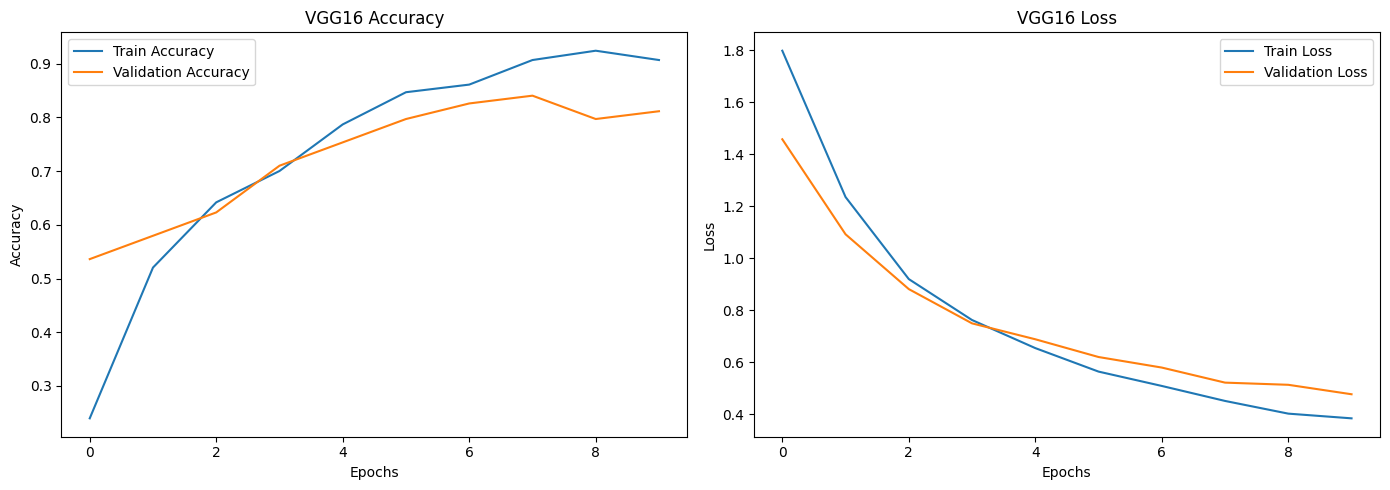

In [30]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_vgg16.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_vgg16.history['loss'], label='Train Loss')
plt.plot(history_vgg16.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


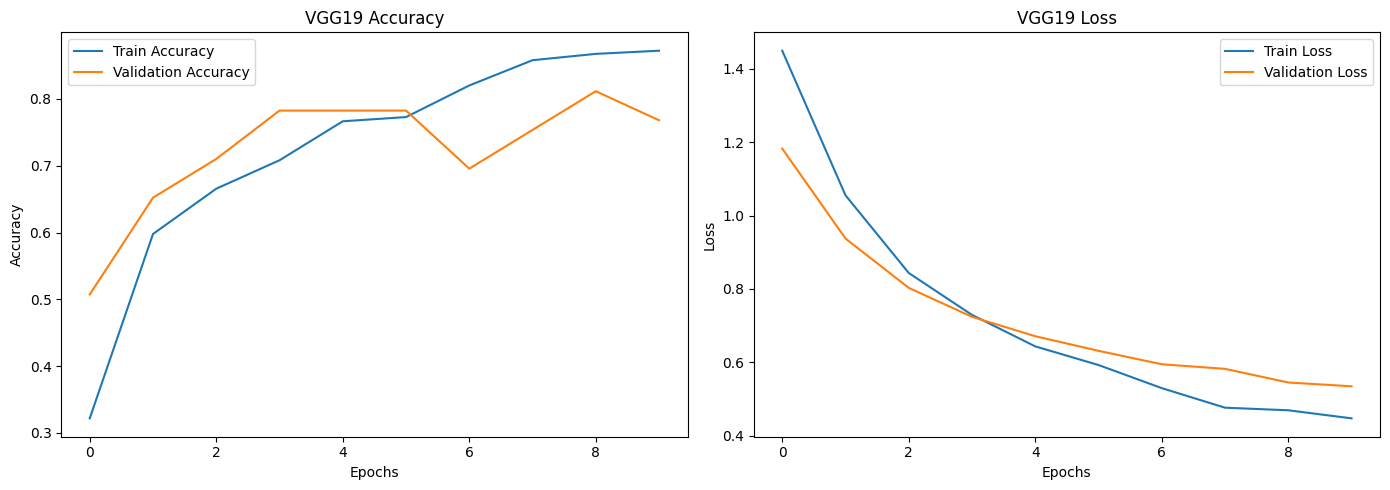

In [31]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_vgg19.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg19.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG19 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_vgg19.history['loss'], label='Train Loss')
plt.plot(history_vgg19.history['val_loss'], label='Validation Loss')
plt.title('VGG19 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


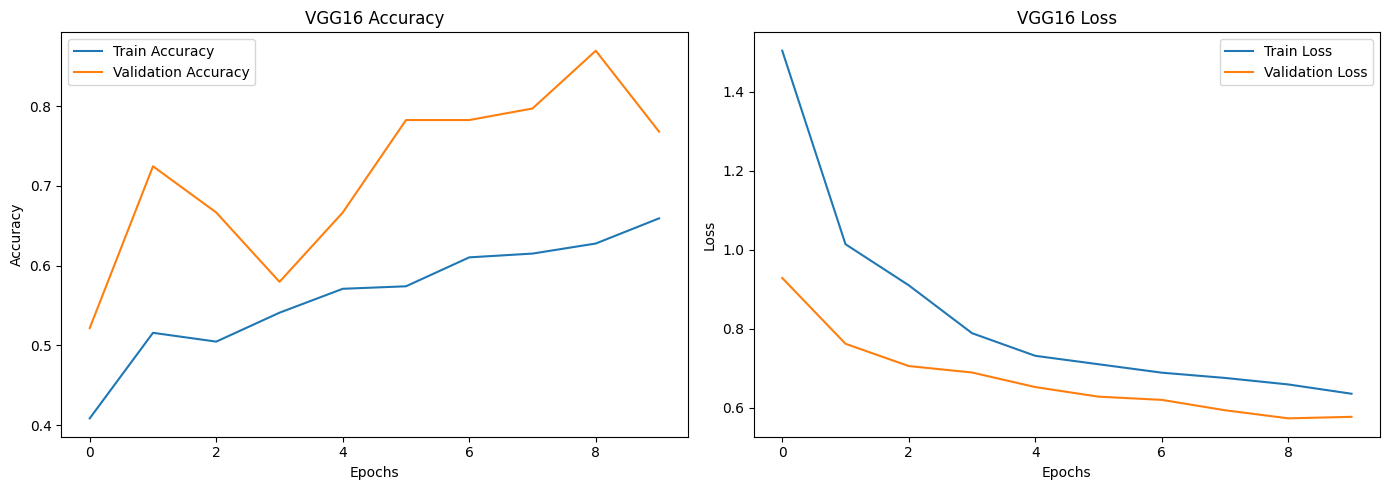

In [32]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
